In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms, models

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
DATASET_PATH = "/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"
classes = ["normal", "benign", "malignant"]

In [4]:
data = []

for label in classes:
    
    folder = os.path.join(DATASET_PATH, label)
    
    for file in os.listdir(folder):
        
        if file.endswith(".png") and "_mask" not in file:
            
            data.append({
                "path": os.path.join(folder, file),
                "label": label
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
df.head()

Total images: 780


,path,label
0,/kaggle/input/datasets/subhajournal/busi-breas...,normal
1,/kaggle/input/datasets/subhajournal/busi-breas...,normal
2,/kaggle/input/datasets/subhajournal/busi-breas...,normal
3,/kaggle/input/datasets/subhajournal/busi-breas...,normal
4,/kaggle/input/datasets/subhajournal/busi-breas...,normal


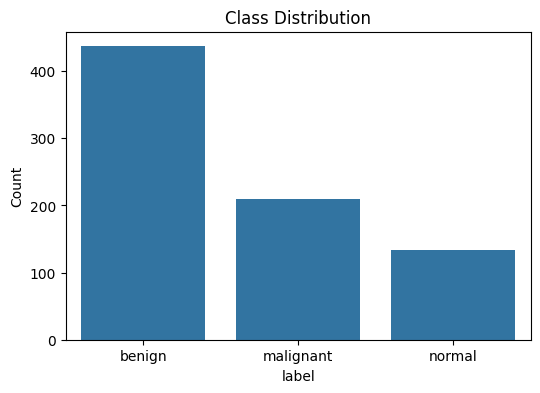

label
benign       437
malignant    210
normal       133
Name: count, dtype: int64


In [5]:
class_counts = df['label'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

print(class_counts)

**Clearly Imbalanced data**

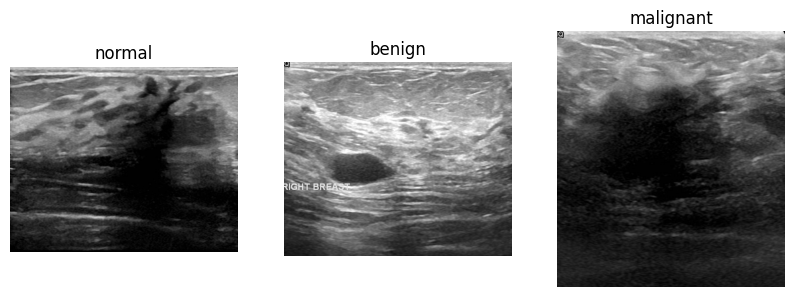

In [6]:
fig, axes = plt.subplots(1,3, figsize=(10,4))

for i, cls in enumerate(classes):
    
    img_path = df[df.label==cls].iloc[0].path
    img = Image.open(img_path)
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.show()

In [8]:
label_map = {
    "normal":0,
    "benign":1,
    "malignant":2
}

df["label_id"] = df["label"].map(label_map)

In [9]:
## 70 / 15 / 15 split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df.label_id,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df.label_id,
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

546 117 117


In [10]:
train_transform = transforms.Compose([
    
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

test_transform = transforms.Compose([
    
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

## Dataset Class

In [11]:
class BUSIDataset(Dataset):
    
    def __init__(self, df, transform=None):
        
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        
        img_path = self.df.iloc[idx].path
        label = self.df.iloc[idx].label_id
        
        img = Image.open(img_path).convert("RGB")
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

In [12]:
train_dataset = BUSIDataset(train_df, train_transform)
val_dataset = BUSIDataset(val_df, test_transform)
test_dataset = BUSIDataset(test_df, test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [13]:
model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 3)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]


In [17]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    
    for epoch in range(epochs):
        
        model.train()
        train_loss = 0
        
        for images, labels in tqdm(train_loader):
            
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        print(f"Epoch {epoch+1} Train Loss:", train_loss/len(train_loader))
        
        evaluate(model, val_loader)

In [18]:
def evaluate(model, loader):
    
    model.eval()
    
    preds = []
    targets = []
    
    with torch.no_grad():
        
        for images, labels in loader:
            
            images = images.to(device)
            
            outputs = model(images)
            
            pred = torch.argmax(outputs, dim=1).cpu().numpy()
            
            preds.extend(pred)
            targets.extend(labels.numpy())
    
    acc = accuracy_score(targets, preds)
    
    print("Accuracy:", acc)

## Baseline Training

In [34]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features,3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 18/18 [01:20<00:00,  4.48s/it]


Epoch 1 Train Loss: 1.0025102181567087
Accuracy: 0.5555555555555556


100%|██████████| 18/18 [01:20<00:00,  4.49s/it]


Epoch 2 Train Loss: 0.47219489845964646
Accuracy: 0.7692307692307693


100%|██████████| 18/18 [01:21<00:00,  4.50s/it]


Epoch 3 Train Loss: 0.6663602424992455
Accuracy: 0.6752136752136753


100%|██████████| 18/18 [01:20<00:00,  4.49s/it]


Epoch 4 Train Loss: 0.4330017351441913
Accuracy: 0.7264957264957265


100%|██████████| 18/18 [01:21<00:00,  4.51s/it]


Epoch 5 Train Loss: 0.4201015145000484
Accuracy: 0.8290598290598291


In [20]:
def full_metrics(model, loader):
    
    model.eval()
    
    preds = []
    targets = []
    
    with torch.no_grad():
        
        for images, labels in loader:
            
            images = images.to(device)
            
            outputs = model(images)
            
            pred = torch.argmax(outputs,1).cpu().numpy()
            
            preds.extend(pred)
            targets.extend(labels.numpy())
            
    acc = accuracy_score(targets,preds)
    precision = precision_score(targets,preds,average="macro")
    recall = recall_score(targets,preds,average="macro")
    f1 = f1_score(targets,preds,average="macro")
    
    cm = confusion_matrix(targets,preds)
    
    print("Accuracy:",acc)
    print("Precision:",precision)
    print("Recall:",recall)
    print("F1:",f1)
    
    sns.heatmap(cm,annot=True,cmap="Blues")
    plt.show()
    
    return acc,precision,recall,f1

## WeightedRandomSampler (Oversampling)

In [21]:
class_counts = train_df.label_id.value_counts().sort_index()

weights = 1.0 / class_counts

sample_weights = train_df.label_id.map(weights)

sampler = WeightedRandomSampler(
    weights=sample_weights.values,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader_sampler = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

In [22]:
model_sampler = models.resnet18(pretrained=True)
model_sampler.fc = nn.Linear(model_sampler.fc.in_features,3)
model_sampler = model_sampler.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_sampler.parameters(), lr=1e-4)

train_model(model_sampler, train_loader_sampler, val_loader, criterion, optimizer)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 18/18 [01:21<00:00,  4.54s/it]


Epoch 1 Train Loss: 0.6075210662351714
Accuracy: 0.7264957264957265


100%|██████████| 18/18 [01:21<00:00,  4.53s/it]


Epoch 2 Train Loss: 0.16933954838249418
Accuracy: 0.8034188034188035


100%|██████████| 18/18 [01:21<00:00,  4.52s/it]


Epoch 3 Train Loss: 0.16021082426110902
Accuracy: 0.8205128205128205


100%|██████████| 18/18 [01:21<00:00,  4.55s/it]


Epoch 4 Train Loss: 0.07177329353160328
Accuracy: 0.8205128205128205


100%|██████████| 18/18 [01:22<00:00,  4.56s/it]


Epoch 5 Train Loss: 0.030247243949108653
Accuracy: 0.8632478632478633


## Data Augmentation

In [23]:
augment_transform = transforms.Compose([
    
    transforms.Resize((224,224)),
    
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(10),
    
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

In [33]:
train_dataset_aug = BUSIDataset(train_df, augment_transform)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)

model_aug = models.resnet18(pretrained=True)
model_aug.fc = nn.Linear(model_aug.fc.in_features,3)
model_aug = model_aug.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_aug.parameters(), lr=1e-4)

train_model(model_aug, train_loader_aug, val_loader, criterion, optimizer)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 18/18 [01:20<00:00,  4.48s/it]


Epoch 1 Train Loss: 1.0555068320698209
Accuracy: 0.7692307692307693


100%|██████████| 18/18 [01:20<00:00,  4.47s/it]


Epoch 2 Train Loss: 0.5861790710025363
Accuracy: 0.811965811965812


100%|██████████| 18/18 [01:20<00:00,  4.48s/it]


Epoch 3 Train Loss: 0.5075991319285499
Accuracy: 0.8803418803418803


100%|██████████| 18/18 [01:20<00:00,  4.46s/it]


Epoch 4 Train Loss: 0.3037816116379367
Accuracy: 0.8632478632478633


100%|██████████| 18/18 [01:20<00:00,  4.47s/it]


Epoch 5 Train Loss: 0.2699031639430258
Accuracy: 0.8803418803418803


## Focal Loss

In [25]:
class FocalLoss(nn.Module):
    
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss()
        
    def forward(self, logits, targets):
        
        ce_loss = self.ce(logits,targets)
        
        pt = torch.exp(-ce_loss)
        
        loss = (1-pt)**self.gamma * ce_loss
        
        return loss

In [31]:
model_focal = models.resnet18(pretrained=True)
model_focal.fc = nn.Linear(model_focal.fc.in_features,3)
model_focal = model_focal.to(device)

criterion = FocalLoss()

optimizer = optim.Adam(model_focal.parameters(), lr=1e-4)

train_model(model_focal, train_loader, val_loader, criterion, optimizer)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 18/18 [01:21<00:00,  4.51s/it]


Epoch 1 Train Loss: 0.4011865134040515
Accuracy: 0.8290598290598291


100%|██████████| 18/18 [01:21<00:00,  4.50s/it]


Epoch 2 Train Loss: 0.056050322173784174
Accuracy: 0.7521367521367521


100%|██████████| 18/18 [01:20<00:00,  4.48s/it]


Epoch 3 Train Loss: 0.02334086730196658
Accuracy: 0.7863247863247863


100%|██████████| 18/18 [01:20<00:00,  4.49s/it]


Epoch 4 Train Loss: 0.011177342320378456
Accuracy: 0.7948717948717948


100%|██████████| 18/18 [01:21<00:00,  4.52s/it]


Epoch 5 Train Loss: 0.02430529250866837
Accuracy: 0.8205128205128205


## Evaluating all models

Accuracy: 0.7692307692307693
Precision: 0.7316660216718267
Recall: 0.7364939719778428
F1: 0.7333333333333334


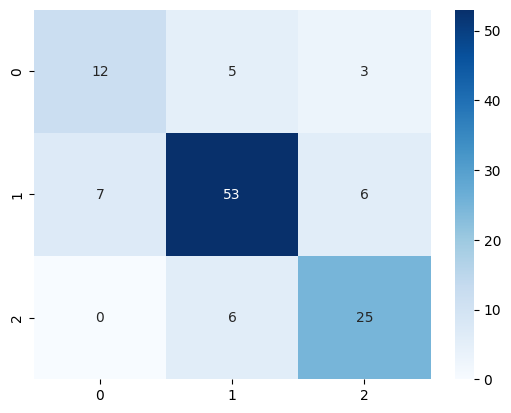

Accuracy: 0.8376068376068376
Precision: 0.8501435927906517
Recall: 0.7650700553926361
F1: 0.7866628307021014


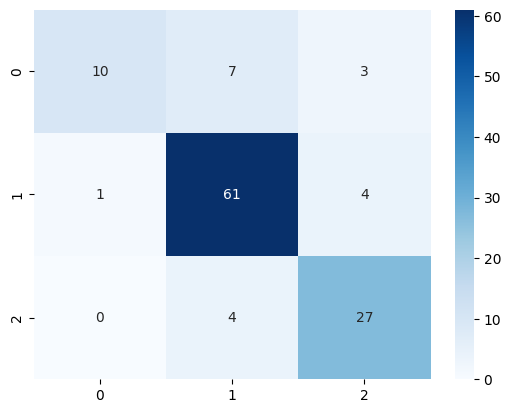

Accuracy: 0.811965811965812
Precision: 0.8081232492997198
Recall: 0.7617464972303681
F1: 0.7763765841026595


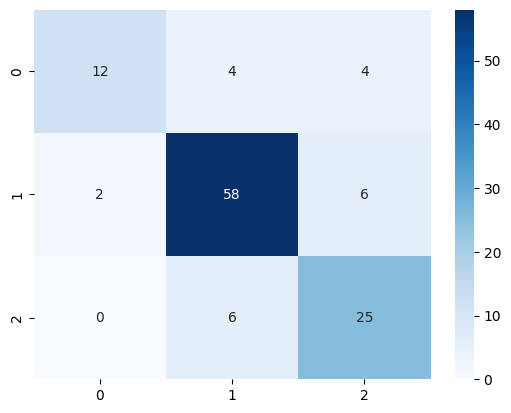

Accuracy: 0.8376068376068376
Precision: 0.8653364179679969
Recall: 0.7711958292603454
F1: 0.8046904953087813


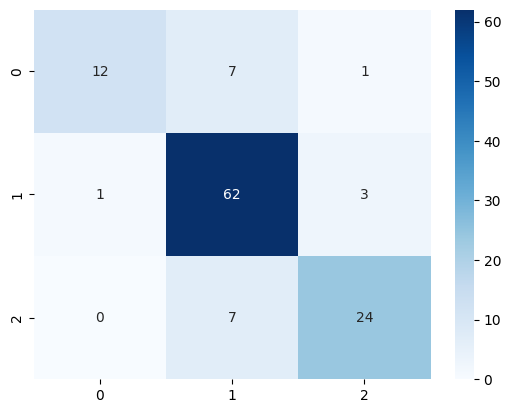

In [35]:
baseline_metrics = full_metrics(model, test_loader)
sampler_metrics = full_metrics(model_sampler, test_loader)
aug_metrics = full_metrics(model_aug, test_loader)
focal_metrics = full_metrics(model_focal, test_loader)